Dataset Shape: (2548, 6)

Columns:
Index(['fr', 'tau_b_star', 'y_star', 'd_star', 'g', 'bed form'], dtype='object')

I column values:
i
-1    1312
 1    1236
Name: count, dtype: int64

Encoded Classes: [0 1 2 3]
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3061 - loss: 1.4850 - val_accuracy: 0.9755 - val_loss: 0.7177
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7127 - loss: 0.9128 - val_accuracy: 0.9632 - val_loss: 0.3054
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9389 - loss: 0.4537 - val_accuracy: 0.9779 - val_loss: 0.1090
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9663 - loss: 0.2202 - val_accuracy: 0.9779 - val_loss: 0.0786
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9690 - loss: 0.1515 - val_accuracy: 0.9804 - val_loss: 0.0725
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9690 - loss: 0.1312 - val_accuracy: 0.9828 - val_loss: 0.0521
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9738 - loss: 0.0960 - val_accuracy: 0.9853 - val_loss: 0.0448
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9679 - loss: 0.1031 - val_accuracy: 0.9828 - val_loss: 0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


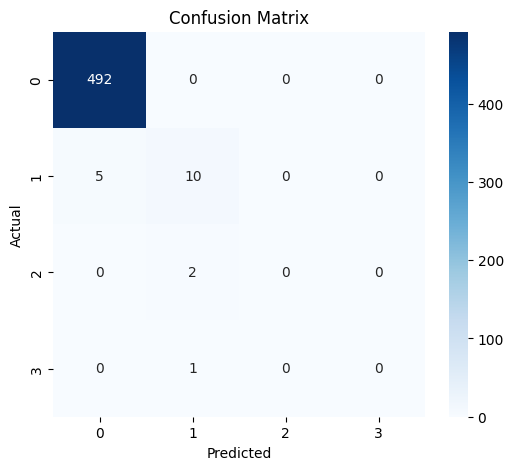

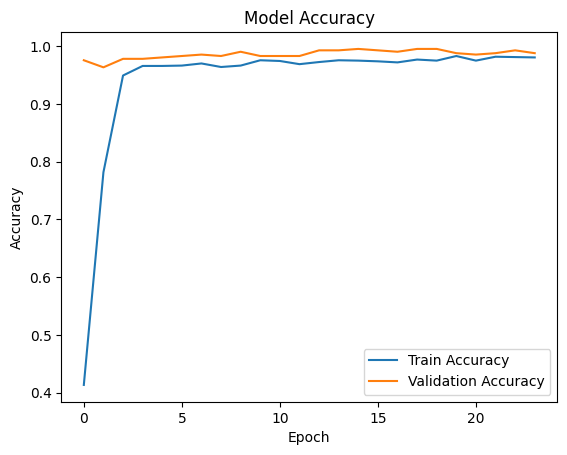

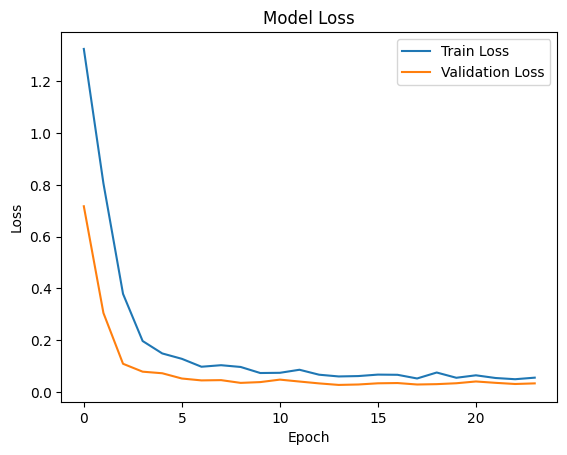

In [6]:
# ==========================================
# 1. Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


# ==========================================
# 2. Load Dataset
# ==========================================

file_path = "/kaggle/input/datasets/afreen456/task-2/Dataset (Task-2).xlsx"

df = pd.read_excel(file_path)

print("Dataset Shape:", df.shape)

# clean column names
df.columns = df.columns.str.strip().str.lower()

print("\nColumns:")
print(df.columns)


# ==========================================
# 3. Create Feature I
# ==========================================

df["i"] = 1
df.loc[0:1311, "i"] = -1

print("\nI column values:")
print(df["i"].value_counts())


# ==========================================
# 4. Features and Target
# ==========================================

features = ["i","fr","tau_b_star","y_star","d_star","g"]

X = df[features]

# Target
y = df["bed form"]

# convert to integer
y = y.astype(int)

# encode labels safely
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("\nEncoded Classes:", np.unique(y))


# ==========================================
# 5. Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==========================================
# 6. Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================================
# 7. PINN Style Neural Network
# ==========================================

num_classes = len(np.unique(y))

model = Sequential([

    Dense(128, activation="tanh", input_shape=(6,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation="tanh"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="tanh"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="tanh"),

    Dense(num_classes, activation="softmax")

])


model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ==========================================
# 8. Early Stopping
# ==========================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


# ==========================================
# 9. Train Model
# ==========================================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


# ==========================================
# 10. Predictions
# ==========================================

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)


# ==========================================
# 11. Evaluation Metrics
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n===== MODEL RESULTS =====")

print("Accuracy:", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))


# ==========================================
# 12. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ==========================================
# 13. Training Accuracy Plot
# ==========================================

plt.figure()

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


# ==========================================
# 14. Training Loss Plot
# ==========================================

plt.figure()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [8]:
# ==========================================
# Imports
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model

from xgboost import XGBClassifier


# ==========================================
# Load Dataset
# ==========================================

file_path = "/kaggle/input/datasets/afreen456/task-2/Dataset (Task-2).xlsx"

df = pd.read_excel(file_path)

df.columns = df.columns.str.strip().str.lower()


# ==========================================
# Create I column
# ==========================================

df["i"] = 1
df.loc[0:1311, "i"] = -1


# ==========================================
# Features
# ==========================================

features = ["i","fr","tau_b_star","y_star","d_star","g"]

X = df[features]

y = df["bed form"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)


# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==========================================
# Scaling
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# PINN Feature Extractor
# ==========================================

inputs = tf.keras.Input(shape=(6,))

x = Dense(128, activation="tanh")(inputs)
x = Dense(128, activation="tanh")(x)
x = Dense(64, activation="tanh")(x)

feature_layer = Dense(32, activation="tanh")(x)

outputs = Dense(len(np.unique(y)), activation="softmax")(feature_layer)

pinn_model = Model(inputs, outputs)


pinn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


pinn_model.fit(
    X_train_scaled,
    y_train,
    epochs=80,
    batch_size=32,
    verbose=1
)


# ==========================================
# Extract Deep Features
# ==========================================

feature_extractor = Model(inputs=pinn_model.input, outputs=feature_layer)

train_features = feature_extractor.predict(X_train_scaled)
test_features = feature_extractor.predict(X_test_scaled)


# ==========================================
# XGBoost Classifier
# ==========================================

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(train_features, y_train)


# ==========================================
# Predictions
# ==========================================

y_pred = xgb.predict(test_features)


# ==========================================
# Evaluation (same format as your ANN)
# ==========================================

precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

precision_weighted = precision_score(y_test, y_pred, average="weighted")
recall_weighted = recall_score(y_test, y_pred, average="weighted")
f1_weighted = f1_score(y_test, y_pred, average="weighted")


print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_macro)

print("\nWeighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_weighted)

Epoch 1/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7058 - loss: 0.7939
Epoch 2/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9855 - loss: 0.0436
Epoch 3/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9893 - loss: 0.0330
Epoch 4/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9833 - loss: 0.0396
Epoch 5/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9879 - loss: 0.0258
Epoch 6/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9864 - loss: 0.0295
Epoch 7/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9955 - loss: 0.0150 
Epoch 8/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9906 - loss: 0.0208
Epoch 9/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9904 - loss: 0.0249
Epoch 10/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9829 - loss: 0.0412
Epoch 11/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9944 - loss: 0.0169 
Epoch 12/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9968 - 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Columns: Index(['fr', 'tau_b_star', 'y_star', 'd_star', 'g', 'bed form'], dtype='object')
Classes: [0 1 2 3]
Epoch 1/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7647 - loss: 0.8660 - val_accuracy: 0.9804 - val_loss: 0.0586
Epoch 2/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9783 - loss: 0.0571 - val_accuracy: 0.9902 - val_loss: 0.0347
Epoch 3/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9921 - loss: 0.0312 - val_accuracy: 0.9902 - val_loss: 0.0336
Epoch 4/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9960 - loss: 0.0186 - val_accuracy: 0.9853 - val_loss: 0.0378
Epoch 5/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9856 - loss: 0.0438 - val_accuracy: 0.9853 - val_loss: 0.0453
Epoch 6/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9894 - loss: 0.0274 - val_accuracy: 0.9951 - val_loss: 0.0239
Epoch 7/120
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9876 - loss: 0.0318 - val_accuracy: 0.9877 - val_loss: 0.0350
Ep

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[I 2026-03-08 10:15:00,195] A new study created in memory with name: no-name-c6e7e2c1-bb07-4cab-9ad6-80dea7a9cc79



===== RESULTS =====
Macro Precision: 0.45537525354969577
Macro Recall: 0.48333333333333334
Macro F1 Score: 0.46849619289340105

Weighted Precision: 0.9869705285765422
Weighted Recall: 0.9921568627450981
Weighted F1 Score: 0.9894617796357122


[I 2026-03-08 10:15:08,070] Trial 0 finished with value: 0.9647058844566345 and parameters: {'units': 203, 'lr': 0.006087438622000232}. Best is trial 0 with value: 0.9647058844566345.
[I 2026-03-08 10:15:15,262] Trial 1 finished with value: 0.9901960492134094 and parameters: {'units': 157, 'lr': 0.005943743425263786}. Best is trial 1 with value: 0.9901960492134094.
[I 2026-03-08 10:15:24,143] Trial 2 finished with value: 0.9843137264251709 and parameters: {'units': 254, 'lr': 0.004305999271668334}. Best is trial 1 with value: 0.9901960492134094.
[I 2026-03-08 10:15:31,070] Trial 3 finished with value: 0.9941176176071167 and parameters: {'units': 130, 'lr': 0.00519495740248878}. Best is trial 3 with value: 0.9941176176071167.
[I 2026-03-08 10:15:39,395] Trial 4 finished with value: 0.9862744808197021 and parameters: {'units': 171, 'lr': 0.0018183877777586722}. Best is trial 3 with value: 0.9941176176071167.
[I 2026-03-08 10:15:46,977] Trial 5 finished with value: 0.9901960492134094 and 


Best Hyperparameters: {'units': 130, 'lr': 0.00519495740248878}


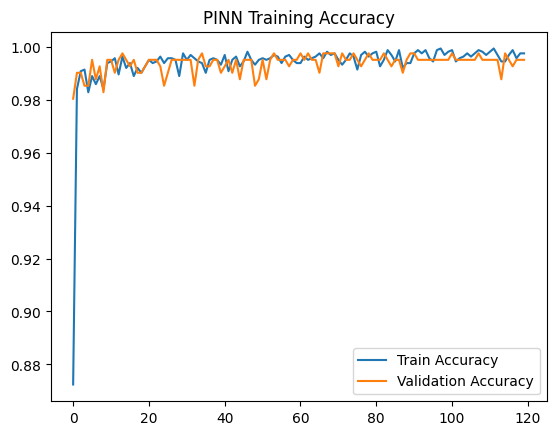

ExactExplainer explainer: 511it [00:18, 18.21it/s]                         


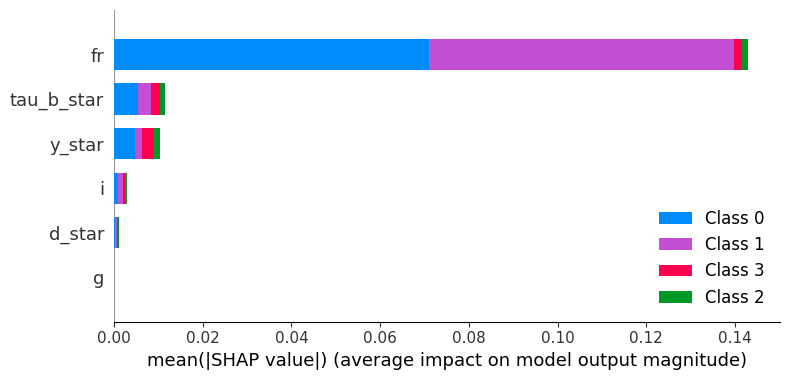

In [10]:
# ==========================================
# 1. Install Required Libraries (Kaggle)
# ==========================================

!pip install optuna shap -q

# ==========================================
# 2. Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import shap
import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score

# ==========================================
# 3. Load Dataset
# ==========================================

file_path = "/kaggle/input/datasets/afreen456/task-2/Dataset (Task-2).xlsx"

df = pd.read_excel(file_path)

# clean column names
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns)

# ==========================================
# 4. Create Feature I
# ==========================================

df["i"] = 1
df.loc[0:1311, "i"] = -1

# ==========================================
# 5. Feature Selection
# ==========================================

features = ["i","fr","tau_b_star","y_star","d_star","g"]

X = df[features]

# ==========================================
# 6. Target Encoding
# ==========================================

y = df["bed form"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Classes:", np.unique(y))

# ==========================================
# 7. Train/Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 8. Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 9. Physics-Informed Loss Function
# ==========================================

def pinn_loss(y_true, y_pred):

    data_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

    physics_term = tf.reduce_mean(tf.square(y_pred))

    return tf.reduce_mean(data_loss) + 0.01 * physics_term

# ==========================================
# 10. PINN Model Builder
# ==========================================

def build_pinn(units=128, lr=0.001):

    inputs = tf.keras.Input(shape=(6,))

    x = tf.keras.layers.Dense(units, activation="tanh")(inputs)
    x = tf.keras.layers.Dense(units, activation="tanh")(x)
    x = tf.keras.layers.Dense(units//2, activation="tanh")(x)
    x = tf.keras.layers.Dense(units//4, activation="tanh")(x)

    outputs = tf.keras.layers.Dense(len(np.unique(y)), activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=pinn_loss,
        metrics=["accuracy"]
    )

    return model

# ==========================================
# 11. Train PINN Model
# ==========================================

model = build_pinn()

history = model.fit(
    X_train,
    y_train,
    epochs=120,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ==========================================
# 12. Predictions
# ==========================================

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

# ==========================================
# 13. Evaluation Metrics
# ==========================================

precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

precision_weighted = precision_score(y_test, y_pred, average="weighted")
recall_weighted = recall_score(y_test, y_pred, average="weighted")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("\n===== RESULTS =====")

print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_macro)

print("\nWeighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_weighted)

# ==========================================
# 14. Hyperparameter Tuning (Optuna)
# ==========================================

def objective(trial):

    units = trial.suggest_int("units", 64, 256)
    lr = trial.suggest_float("lr", 1e-4, 1e-2)

    model = build_pinn(units, lr)

    model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)

    _, acc = model.evaluate(X_test, y_test, verbose=0)

    return acc

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=15)

print("\nBest Hyperparameters:", study.best_params)

# ==========================================
# 15. Training Curves
# ==========================================

plt.figure()

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.legend()
plt.title("PINN Training Accuracy")

plt.show()

# ==========================================
# 16. Feature Importance (SHAP)
# ==========================================

explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)